# APRENDIZAJE NO SUPERVISADO
## CLUSTERIZACIÓN
### K-MEANS

El conjunto de datos contiene 2000 observaciones.

El propietario de un supermercado, a través de las tarjetas de socio, dispone de algunos datos básicos sobre sus clientes. Quiere entender mejor a los clientes y saber quiénes son los clientes objetivo para que el equipo de marketing pueda interpretarlo y planificar la estrategia en consecuencia.

Características del conjunto de datos:

* **ID** Muestra un identificador único de un cliente.
* **Sex** Sexo biológico de un cliente. En este conjunto de datos solo hay 2 opciones diferentes.  
  `0` male  
  `1` female
* **Marital status** Estado civil de un cliente.  
  `0` single  
  `1` non-single (divorced / separated / married / widowed)
* **Age** Edad del cliente en años, calculada como el año actual menos el año de nacimiento del cliente en el momento de creación del conjunto de datos.  
  `18` Min value  
  `76` Max value
* **Education** Nivel educativo del cliente.  
  `0` other / unknown  
  `1` high school  
  `2` university  
  `3` graduate school
* **Income** Ingreso anual declarado por el cliente en dólares estadounidenses.
* **Occupation** Categoría ocupacional del cliente.  
  `0` unemployed / unskilled  
  `1` skilled employee / official  
  `2` management / self-employed / highly qualified employee / officer
* **Settlement size** Tamaño de la ciudad en la que vive el cliente.  
  `0` small city  
  `1` mid-sized city  
  `2` big city

El objetivo es encontrar similitudes entre los clientes, agrupándolos para poder realizar un marketing dirigido.

# Fase 1. Recopilación de los datos

In [1]:
# Importación de les bibliotecas
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
import matplotlib.cm as cm
from sklearn.metrics import silhouette_samples
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

ruta = '/content/drive/MyDrive/CURSO_MACHINE_LEARNING/CSV/customers.csv'
df = pd.read_csv(ruta)

Mounted at /content/drive


# Fase 2. Exploración y preparación de los datos

## Limpieza inicial de los datos

In [3]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   ID               2000 non-null   int64
 1   Sex              2000 non-null   int64
 2   Marital status   2000 non-null   int64
 3   Age              2000 non-null   int64
 4   Education        2000 non-null   int64
 5   Income           2000 non-null   int64
 6   Occupation       2000 non-null   int64
 7   Settlement size  2000 non-null   int64
dtypes: int64(8)
memory usage: 125.1 KB


In [ ]:
# Eliminar columna ID
df = df.drop(["ID"], axis = 1)

In [ ]:
# Mostra las filas duplicadas
duplicados = df[df.duplicated()]
print("Filas duplicadas:")
print(duplicados)

Filas duplicadas:
Empty DataFrame
Columns: [Sex, Marital status, Age, Education, Income, Occupation, Settlement size]
Index: []


In [ ]:
# Muestra el número de valores nulos (NaN) en cada columna del DataFrame
df.isnull().sum()

,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


In [ ]:
# Reemplaza strings vacíos por NaN para que también se consideren valores nulos
# Y volver a comprobar
df.replace("", np.nan, inplace=True)
df.isnull().sum()

,0
Sex,0
Marital status,0
Age,0
Education,0
Income,0
Occupation,0
Settlement size,0


## Análisis exploratorio de los datos


### Visualizar distribuciones

In [ ]:
"""
La mayoría de variables tienen pocos valores distintos, excepto 'Income',
que presenta una gran cantidad de valores únicos. Esto es esperable si se mide en dólares los ingresos,
por lo que no se considera un problema.
"""
# Número de elementos únicos por cada característica
for column in df.columns:
    print(f'{column}---> {df[column].nunique()}')

Sex---> 2
Marital status---> 2
Age---> 58
Education---> 4
Income---> 1982
Occupation---> 3
Settlement size---> 3


In [ ]:
# Creación de una función para mostrar datos en lugar de números y hacer los gráficos más comprensibles.
def create_temp_df(temp_df):
    temp_df = temp_df.copy()
    temp_df['Sex'] = temp_df['Sex'].replace(0, 'Male')
    temp_df['Sex'] = temp_df['Sex'].replace(1, 'Female')
    temp_df['Marital status'] = temp_df['Marital status'].replace(0, 'Single')
    temp_df['Marital status'] = temp_df['Marital status'].replace(1, 'Non-Single')
    temp_df['Education'] = temp_df['Education'].replace(0, 'Other/Unknown')
    temp_df['Education'] = temp_df['Education'].replace(1, 'High School')
    temp_df['Education'] = temp_df['Education'].replace(2, 'University')
    temp_df['Education'] = temp_df['Education'].replace(3, 'Graduate School')
    temp_df['Occupation'] = temp_df['Occupation'].replace(0, 'Unskilled Employee')
    temp_df['Occupation'] = temp_df['Occupation'].replace(1, 'Skilled Employee')
    temp_df['Occupation'] = temp_df['Occupation'].replace(2, 'Highly Qualified Employee')
    temp_df['Settlement size'] = temp_df['Settlement size'].replace(0, 'Small City')
    temp_df['Settlement size'] = temp_df['Settlement size'].replace(1, 'Mid-Sized City')
    temp_df['Settlement size'] = temp_df['Settlement size'].replace(2, 'Big City')
    return temp_df

In [ ]:
# Llama a la función pasándole el dataframe original, así no lo modificamos para después usarlo con los clústers.
temp_df = create_temp_df(df)

In [ ]:
temp_df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,Male,Single,67,University,124670,Skilled Employee,Big City
1,Female,Non-Single,22,High School,150773,Skilled Employee,Big City
2,Male,Single,49,High School,89210,Unskilled Employee,Small City
3,Male,Single,45,High School,171565,Skilled Employee,Mid-Sized City
4,Male,Single,53,High School,149031,Skilled Employee,Mid-Sized City
...,...,...,...,...,...,...,...
1995,Female,Single,47,High School,123525,Unskilled Employee,Small City
1996,Female,Non-Single,27,High School,117744,Skilled Employee,Small City
1997,Male,Single,31,Other/Unknown,86400,Unskilled Employee,Small City
1998,Female,Non-Single,24,High School,97968,Unskilled Employee,Small City


In [ ]:
temp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Sex              2000 non-null   object
 1   Marital status   2000 non-null   object
 2   Age              2000 non-null   int64 
 3   Education        2000 non-null   object
 4   Income           2000 non-null   int64 
 5   Occupation       2000 non-null   object
 6   Settlement size  2000 non-null   object
dtypes: int64(2), object(5)
memory usage: 109.5+ KB


In [ ]:
# Columnas categóricas (tipo object)
cat_cols_temp = temp_df.select_dtypes(include='object').columns.tolist()
# Columnas numéricas (tipo numérico)
num_cols_temp = temp_df.select_dtypes(include='number').columns.tolist()

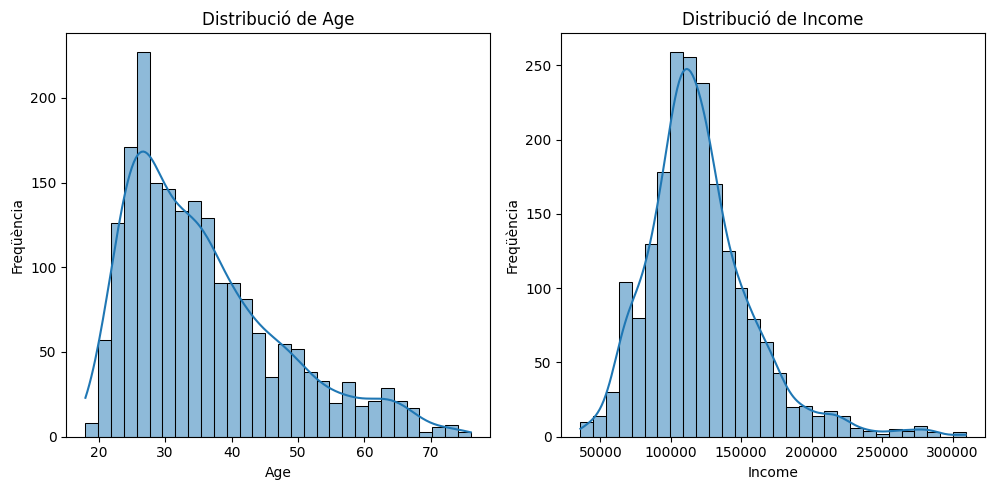

In [ ]:
# Edad: Distribución asimétrica con un pico alrededor de los 30 años. Mayor concentración entre los 20 y los 40 -> escalar minMax
# Ingresos: Distribución sesgada a la derecha, con un gran grupo de usuarios entre los 80.000 y 150.000 minutos mensuales.

import matplotlib.pyplot as plt
import seaborn as sns

num_cols_per_row = 3
num_rows = (len(num_cols_temp) + num_cols_per_row - 1) // num_cols_per_row

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))

axes = axes.flatten()

for i, col in enumerate(num_cols_temp):
    sns.histplot(df[col], bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'Distribució de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Freqüència')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

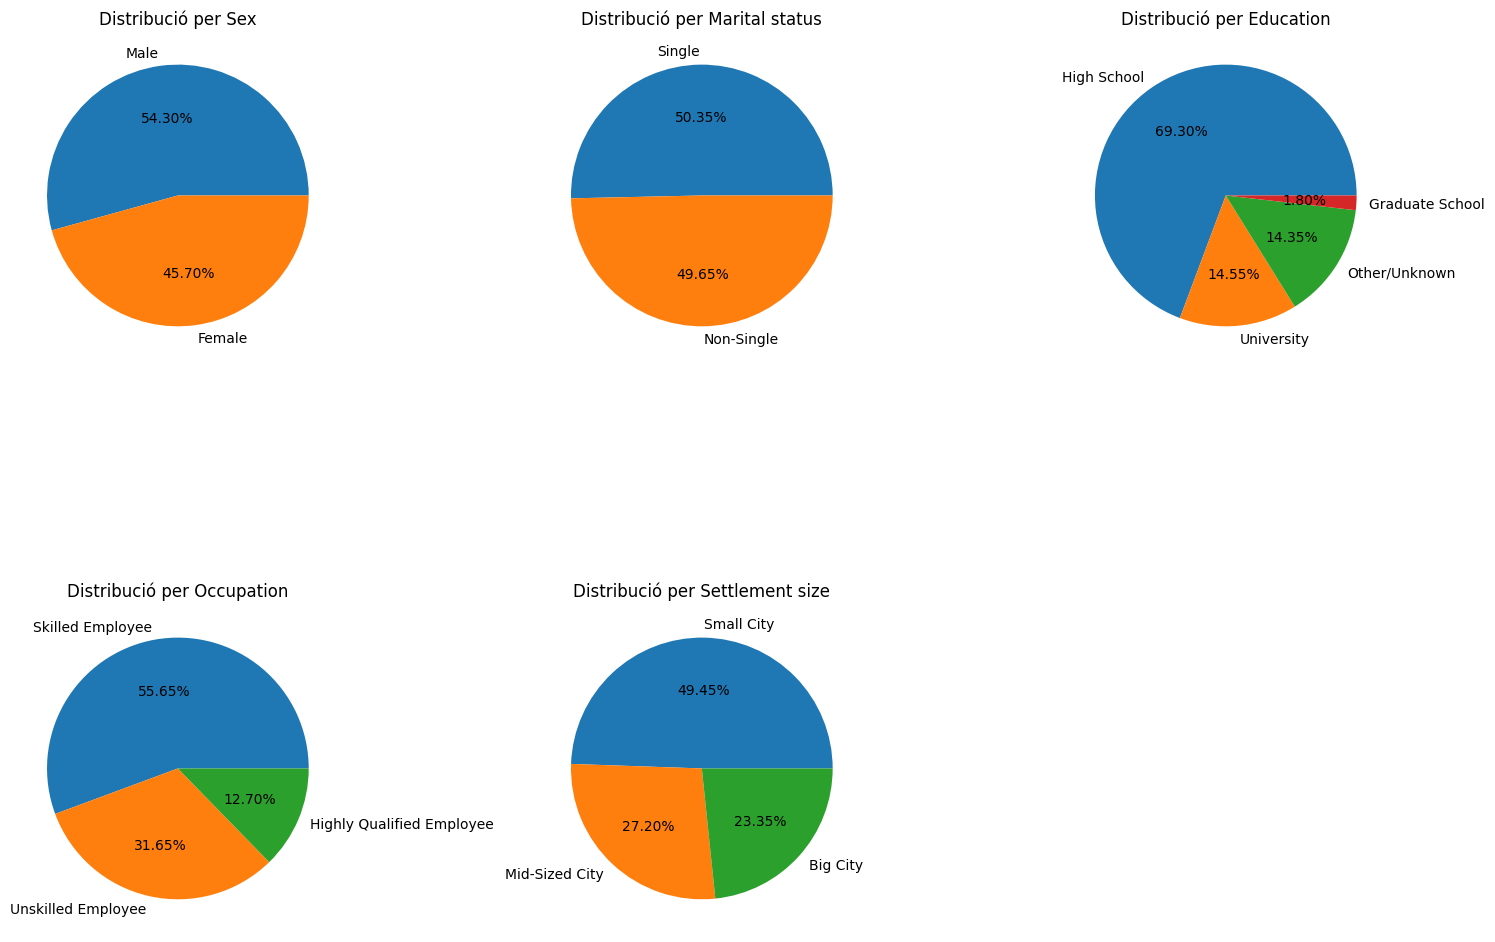

In [ ]:
# Sexo: distribución equilibrada, con una ligera mayoría del grupo 0 (54.3%).
# Estado civil: casi completamente equilibrado, apenas hay diferencia entre ambos estados.

# Educación: clara mayoría del grupo 1 (69.3%), el resto de niveles son mucho menos frecuentes.
# Característica muy desbalanceada. A tener en cuenta, que el algortimo no tienda a hacer clústeres alrededor de ella. Escalar?

# Ocupación: predominio del grupo 1 (55.65%), con el grupo 2 representando solo el 12.7%.
# Tamaño del asentamiento: distribución más repartida, aunque el valor 0 es el más frecuente (49.45%).


import matplotlib.pyplot as plt

num_cols_per_row = 3
num_rows = (len(cat_cols_temp) + num_cols_per_row - 1) // num_cols_per_row  # Calcular files necessàries

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 6 * num_rows))

axes = axes.flatten()

for i, col in enumerate(cat_cols_temp):
    counts = temp_df[col].value_counts()
    labels = counts.index.astype(str)

    axes[i].pie(counts, labels=labels, autopct='%.2f%%')
    axes[i].set_title(f'Distribució per {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Detectar outliers

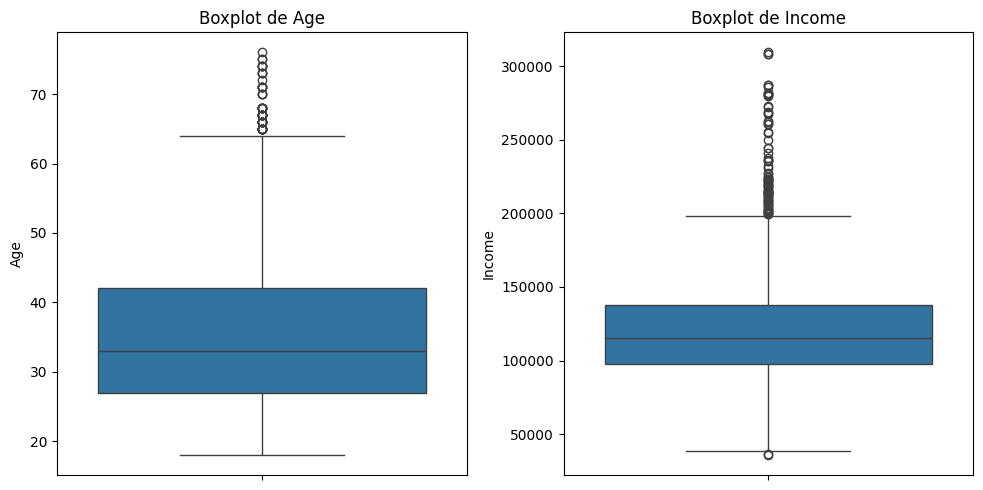

In [ ]:
"""
Edat: Distribución centrada entre 30 y 45 años. Outliers solo por encima de los 65 años.
Ingresos: Diversos outliers
"""
num_cols_per_row = 3
num_rows = (len(num_cols_temp) + num_cols_per_row - 1) // num_cols_per_row  # Calcular files necessàries

fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols_per_row, figsize=(15, 5 * num_rows))
axes = axes.flatten()

# Generar boxplots per a cada variable numèrica
for i, col in enumerate(num_cols_temp):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot de {col}')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
# De momento mantenemos por si representan casos reales
outliers_count = {}

for col in num_cols_temp:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outliers_count[col] = len(outliers)

outliers_count = dict(sorted(outliers_count.items(), key=lambda x: x[1], reverse=True))

for col, count in outliers_count.items():
    percent = (count / len(df)) * 100
    print(f'{col}: {count} outliers ({percent:.2f}%)')


Income: 83 outliers (4.15%)
Age: 57 outliers (2.85%)


### Escalar los datos

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# Filtrar solo columnas numéricas, que son todas en este caso
X_num = df.select_dtypes(include='number')

# Crear instancia y aplicar escalado
scaler = MinMaxScaler()
X_features = scaler.fit_transform(X_num)

In [ ]:
X_features

array([[0.        , 0.        , 0.84482759, ..., 0.32478101, 0.5       ,
        1.        ],
       [1.        , 1.        , 0.06896552, ..., 0.42021043, 0.5       ,
        1.        ],
       [0.        , 0.        , 0.53448276, ..., 0.19514353, 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.22413793, ..., 0.18487051, 0.        ,
        0.        ],
       [1.        , 1.        , 0.10344828, ..., 0.22716172, 0.        ,
        0.        ],
       [0.        , 0.        , 0.12068966, ..., 0.11912317, 0.        ,
        0.        ]])

## Mirar correlaciones

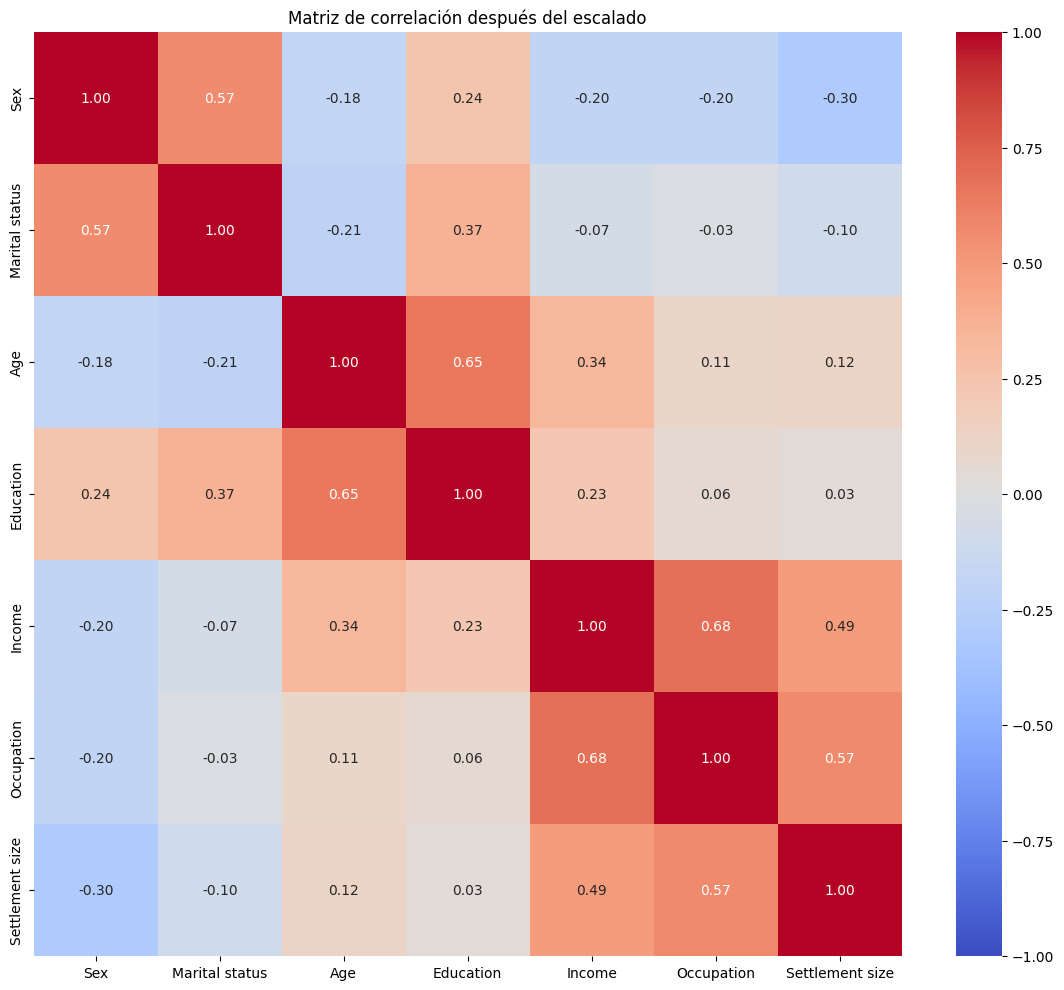

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Recuperar nombres de columnas del DataFrame original
column_names = X_num.columns

# Convertir X_features (array) en DataFrame
df_scaled = pd.DataFrame(X_features, columns=column_names)

# Calcular y mostrar la matriz de correlación
plt.figure(figsize=(14, 12))
sns.heatmap(df_scaled.corr(),
            cmap='coolwarm',
            center=0,
            vmax=1,
            vmin=-1,
            annot=True,
            fmt=".2f")
plt.title("Matriz de correlación después del escalado")
plt.show()



# Fase 3. División de los datos de entrenamiento y prueba
En aprendizaje no supervisado no existe esta fase.


# Fase 4. Entrenamiento del modelo y realización de predicciones


In [ ]:
# n_clusters: número de grupos a formar. En este caso, se probará con 4.

# n_init: el algoritmo K-Means se ejecutará 10 veces con centroides iniciales distintos
# y se seleccionará el modelo con la inercia más baja.

# max_iter: número máximo de iteraciones permitidas por cada inicialización.
# Útil si el algoritmo necesita más pasos para converger o se quiere limitar el tiempo.

# init: método de inicialización de centroides. Aquí se usa 'k-means++', que es el valor por defecto mejorado.

# algorithm: especifica el algoritmo usado para calcular los clústers.
# 'lloyd' equivale al K-Means clásico. Es el predeterminado, no es necesario cambiarlo.

kmeans = KMeans(n_clusters=4, n_init=10, init='k-means++', max_iter=500, random_state=42, algorithm='lloyd')
kmeans_labels = kmeans.fit_predict(X_features)
df['kmeans_labels'] = kmeans_labels

In [ ]:
df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,kmeans_labels
0,0,0,67,2,124670,1,2,2
1,1,1,22,1,150773,1,2,0
2,0,0,49,1,89210,0,0,1
3,0,0,45,1,171565,1,1,2
4,0,0,53,1,149031,1,1,2
...,...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0,1
1996,1,1,27,1,117744,1,0,0
1997,0,0,31,0,86400,0,0,1
1998,1,1,24,1,97968,0,0,0


# Fase 5. Validación del modelo


In [ ]:
# Cálculo de métricas internas

# Calcula el coeficiente de silhouette
silhouette = silhouette_score(X_features, df['kmeans_labels'])
print(f"Silhouette Score: {silhouette}")

# Calcula el índice de Davies-Bouldin
davies_bouldin = davies_bouldin_score(X_features, df['kmeans_labels'])
print(f"Davies-Bouldin Score: {davies_bouldin}")

# Calcula el índice de Calinski-Harabasz
calinski_harabasz = calinski_harabasz_score(X_features, df['kmeans_labels'])
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

# Obtiene la inercia (SSE)
inertia = kmeans.inertia_

# Imprime la inercia
print(f"Inercia (SSE): {inertia}")

Silhouette Score: 0.4023684317095256
Davies-Bouldin Score: 1.0860130896268632
Calinski-Harabasz Score: 1169.3724832325852
Inercia (SSE): 627.4824486201511


**Silhouette Score (0.40)**:
Oscila entre -1 y 1. Valores > 0.5 indican clústers bien definidos. Entre 0.3 y 0.5 es aceptable. Aquí muestra separación razonable.

**Davies-Bouldin (1.08)**: Rango positivo, cuanto más bajo mejor. < 1 es excelente, 1–2 es correcto. El valor obtenido sugiere separación adecuada.

**Calinski-Harabasz (1169.37)**: No tiene límite superior. Cuanto más alto, mejor separación y cohesión. Valor muy bueno, indica grupos bien estructurados.

**Inercia (SSE = 627.48)**: Sin rango fijo. Solo se interpreta comparando entre distintos k en la gráfica del codo.

Los resultados obtenidos indican que el modelo de clustering con k=4 es una opción válida y de buena calidad. El coeficiente de silhouette se sitúa en un valor aceptable (0.40), lo que sugiere una separación razonable entre los grupos. El índice de Davies-Bouldin es bajo (1.08), señal de que los clústers son compactos y están bien diferenciados. Además, el valor elevado del índice de Calinski-Harabasz (1169.37) refuerza la idea de que existe una estructura clara en los datos. En conjunto, estas métricas respaldan que el modelo genera una segmentación coherente y útil para continuar con el análisis.

# Fase 6 y Fase 7. Optimización del modelo y prueba del nuevo modelo


In [ ]:
df = df.drop(['kmeans_labels'], axis=1)

In [ ]:
df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1
...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0
1996,1,1,27,1,117744,1,0
1997,0,0,31,0,86400,0,0
1998,1,1,24,1,97968,0,0


In [ ]:
# Creación de una función para encontrar el valor óptimo de k
def visualize_silhouette(model, cluster_lists, X_features):

    n_cols = len(cluster_lists)

    fig, axs = plt.subplots(figsize=(4*n_cols,4), nrows=1, ncols=n_cols)

    for ind, n_cluster in enumerate(cluster_lists):

        cluster = KMeans(n_clusters=n_cluster, n_init=10, max_iter=500, random_state=0)
        cluster_labels = cluster.fit_predict(X_features)

        sil_avg = silhouette_score(X_features, cluster_labels)
        sil_values = silhouette_samples(X_features, cluster_labels)

        y_lower = 10
        axs[ind].set_title('Number of Cluster: '+str(n_cluster) + ' Silhouette Score: '+ str(round(sil_avg,3)),
                           fontsize=10)
        axs[ind].set_xlabel('The silhouette coefficient value')

        for i in range(n_cluster):
            ith_cluster_sil_values = sil_values[cluster_labels==i]
            ith_cluster_sil_values.sort()

            size_cluster_i = ith_cluster_sil_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color=  cm.nipy_spectral(float(i)/n_cluster)
            axs[ind].fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_sil_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
            y_lower = y_upper + 10
        axs[ind].axvline(x=sil_avg, color="red", linestyle="--")

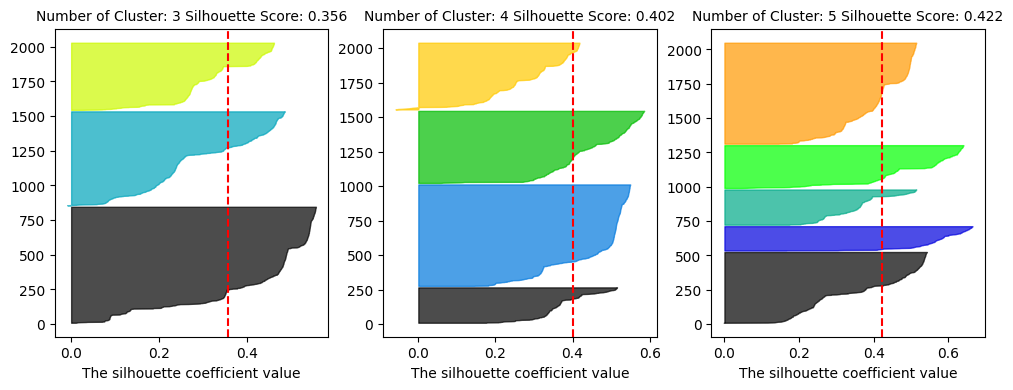

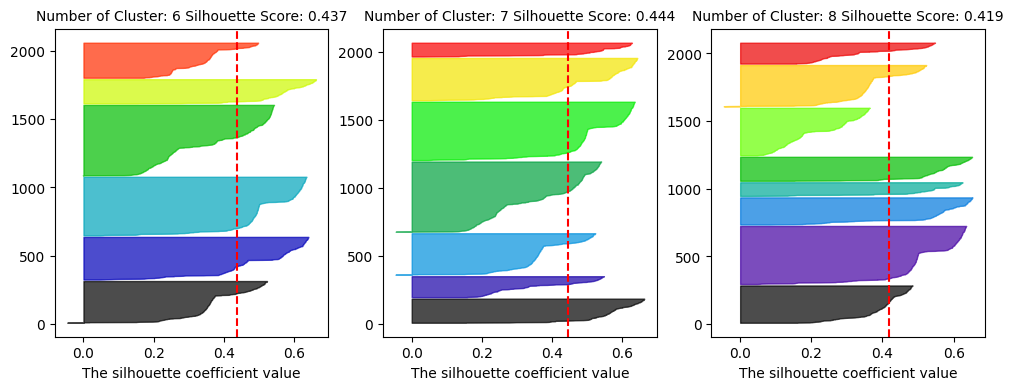

In [ ]:
"""
La altura de cada "cuchilla" indica el número de instancias
El ancho indica los coeficientes
La línea discontinua indica la puntuación media de Silhouette para cada clúster
Todos los clústers deben superarla, si no, no se consideran buenos
"""
visualize_silhouette('KMeans', [3,4,5], X_features)
visualize_silhouette('KMeans', [6,7,8], X_features)

In [ ]:
# Prueba con el nuevo modelo
kmeans = KMeans(n_clusters=7, n_init=10, init='k-means++', max_iter=500, random_state=42, algorithm='lloyd')
kmeans_labels = kmeans.fit_predict(X_features)
df['kmeans_labels'] = kmeans_labels

In [ ]:
df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,kmeans_labels
0,0,0,67,2,124670,1,2,5
1,1,1,22,1,150773,1,2,1
2,0,0,49,1,89210,0,0,0
3,0,0,45,1,171565,1,1,3
4,0,0,53,1,149031,1,1,3
...,...,...,...,...,...,...,...,...
1995,1,0,47,1,123525,0,0,4
1996,1,1,27,1,117744,1,0,2
1997,0,0,31,0,86400,0,0,0
1998,1,1,24,1,97968,0,0,2


In [ ]:
# Cálculo de métricas internas

# Calcula el coeficiente de silhouette
silhouette = silhouette_score(X_features, df['kmeans_labels'])
print(f"Silhouette Score: {silhouette}")

# Calcula el índice de Davies-Bouldin
davies_bouldin = davies_bouldin_score(X_features, df['kmeans_labels'])
print(f"Davies-Bouldin Score: {davies_bouldin}")

# Calcula el índice de Calinski-Harabasz
calinski_harabasz = calinski_harabasz_score(X_features, df['kmeans_labels'])
print(f"Calinski-Harabasz Score: {calinski_harabasz}")

# Obtiene la inercia (SSE)
inertia = kmeans.inertia_

# Imprime la inercia
print(f"Inercia (SSE): {inertia}")

Silhouette Score: 0.40868058259901213
Davies-Bouldin Score: 0.9974471392638469
Calinski-Harabasz Score: 1212.6054434984858
Inercia (SSE): 372.0663266466195


**Silhouette Score**: 0.4087  
Valor aceptable, indica que los clústers están moderadamente separados y definidos

**Davies-Bouldin Score**: 0.9974  
Valor cercano a 1, razonable, muestra que los clústers son relativamente compactos y bien separados

**Calinski-Harabasz Score**: 1212.61  
Valor alto, indica buena cohesión interna y buena separación entre clústers

**Inercia (SSE)**: 372.07  
Valor útil para comparar con otras configuraciones, conviene ver si forma un "codo" claro en el gráfico

Los resultados indican una agrupación bastante coherente. Los clústers están bien definidos y separados, con una estructura interna clara. El Silhouette es moderado pero aceptable, el Davies-Bouldin es razonable y el Calinski-Harabasz destaca por su valor alto. La inercia se puede usar para comparar con otras posibles configuraciones, pero en conjunto, este modelo ofrece una segmentación válida.


El modelo con 7 clústers segmenta mejor que el de 4. Los grupos son más claros, compactos y diferenciados. Vale la pena considerar este número como una opción sólida para el análisis final. Mejora el Silhouette, baja el Davies-Bouldin y sube el Calinski-Harabasz. Todo indica una mejor estructura general. El modelo con 7 clústers ofrece más detalle, mejor separación y mayor coherencia interna.










### Elbow como complemento

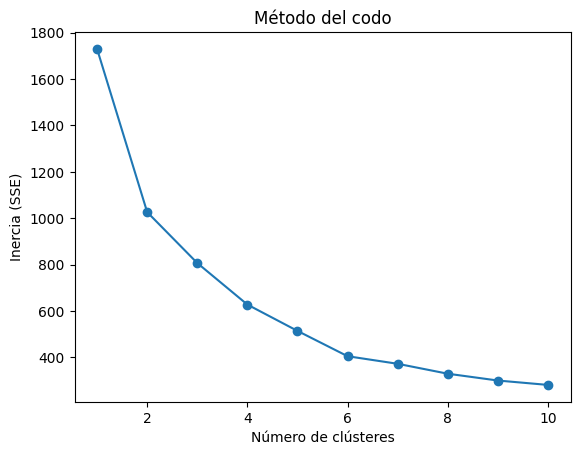

In [ ]:
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, max_iter=500, random_state=42, algorithm='lloyd')
    kmeans.fit(X_features)
    sse.append(kmeans.inertia_)

# Visualitzar la corba del colze
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Número de clústeres')
plt.ylabel('Inercia (SSE)')
plt.title('Método del codo')
plt.show()

El gráfico del codo sugiere que 4 clústers son suficientes para representar bien la variabilidad global, mientras que el análisis con Silhouette indica que 7 clústers ofrecen agrupaciones más coherentes y separadas. Por tanto, si se prioriza la simplicidad del modelo, 4 puede ser una buena opción, pero si se busca una segmentación más precisa y útil para el análisis, 7 clústers resultan más adecuados.

## PCA para terminar de decidir

Valores únicos en "kmeans_labels":
kmeans_labels
2    430
3    352
1    306
5    276
6    257
0    201
4    178
Name: count, dtype: int64


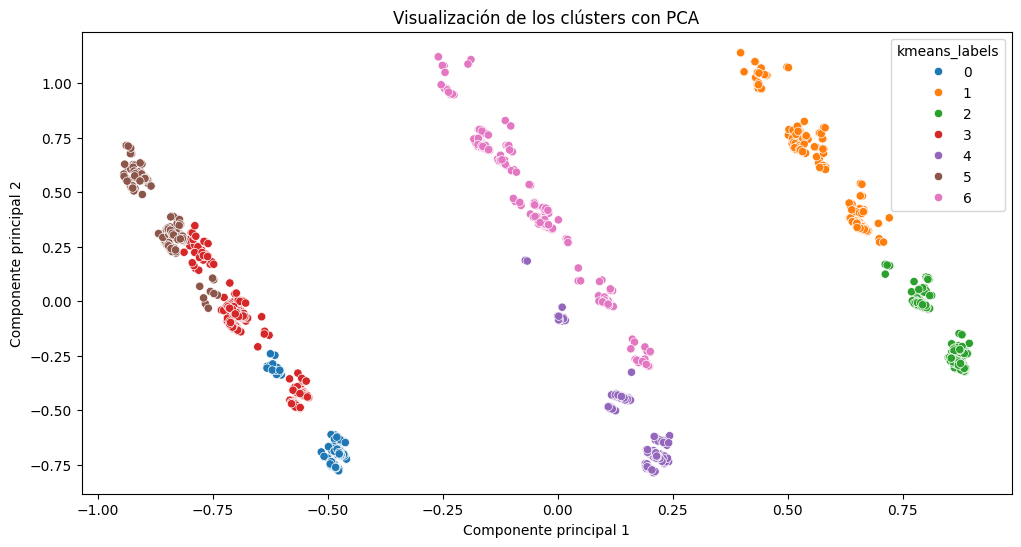

In [ ]:
# Crear nuevo DataFrame con las etiquetas
nuevo_df = pd.DataFrame()
nuevo_df['kmeans_labels'] = df['kmeans_labels'].copy()

# Mostrar la distribución de etiquetas
print('Valores únicos en "kmeans_labels":')
print(nuevo_df['kmeans_labels'].value_counts())

# Aplicar PCA sobre las variables escaladas (sin incluir etiquetas)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)
nuevo_df['PCA1'] = X_pca[:, 0]
nuevo_df['PCA2'] = X_pca[:, 1]

# Representación en 2D
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='kmeans_labels', data=nuevo_df, palette='tab10', legend='full')
plt.title('Visualización de los clústers con PCA')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

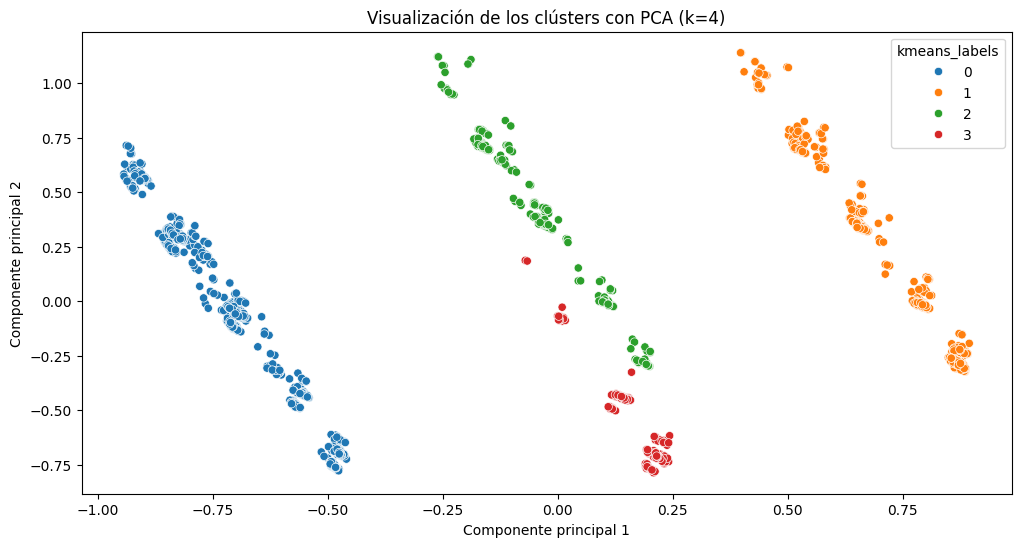

In [ ]:
# Eliminar etiquetas antiguas si existen
if 'kmeans_labels' in df.columns:
    df = df.drop(columns=['kmeans_labels'])

# Aplicar K-means con 4 clústers sobre los datos escalados
kmeans = KMeans(n_clusters=4, random_state=42)
labels_4 = kmeans.fit_predict(X_features)

# Añadir nuevas etiquetas al DataFrame
df['kmeans_labels'] = labels_4
nuevo_df = pd.DataFrame()
nuevo_df['kmeans_labels'] = labels_4

# PCA sobre los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_features)
nuevo_df['PCA1'] = X_pca[:, 0]
nuevo_df['PCA2'] = X_pca[:, 1]

# Representación gráfica de los nuevos clústers
plt.figure(figsize=(12, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='kmeans_labels', data=nuevo_df, palette='tab10', legend='full')
plt.title('Visualización de los clústers con PCA (k=4)')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.show()

# Fase 8. Conclusiones


A falta de hacer más optimizaciones, borrando outliers, utilizando One-Hot-Encoder..., nos quedamos con 4 clústeres.

# Representación gráfica y qualitativa de los clústeres

In [ ]:
temp_df['kmeans_labels'] = df['kmeans_labels']

In [ ]:
temp_df

,Sex,Marital status,Age,Education,Income,Occupation,Settlement size,kmeans_labels
0,Male,Single,67,University,124670,Skilled Employee,Big City,0
1,Female,Non-Single,22,High School,150773,Skilled Employee,Big City,1
2,Male,Single,49,High School,89210,Unskilled Employee,Small City,0
3,Male,Single,45,High School,171565,Skilled Employee,Mid-Sized City,0
4,Male,Single,53,High School,149031,Skilled Employee,Mid-Sized City,0
...,...,...,...,...,...,...,...,...
1995,Female,Single,47,High School,123525,Unskilled Employee,Small City,3
1996,Female,Non-Single,27,High School,117744,Skilled Employee,Small City,1
1997,Male,Single,31,Other/Unknown,86400,Unskilled Employee,Small City,0
1998,Female,Non-Single,24,High School,97968,Unskilled Employee,Small City,1


In [ ]:
# Creación de los 4 clústeres
cluster_0 = temp_df.loc[temp_df['kmeans_labels']==0]
cluster_1 = temp_df.loc[temp_df['kmeans_labels']==1]
cluster_2 = temp_df.loc[temp_df['kmeans_labels']==2]
cluster_3 = temp_df.loc[temp_df['kmeans_labels']==3]

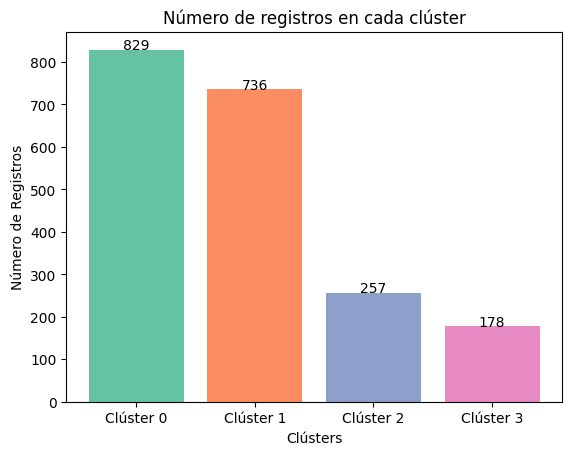

In [ ]:
# Crear una lista con los nombres de los clústers y el número de registros en cada uno
clusters = ['Clúster 0', 'Clúster 1', 'Clúster 2', 'Clúster 3']
num_rows = [len(cluster_0), len(cluster_1), len(cluster_2), len(cluster_3)]

# Visualizar el número de registros con un diagrama de barras y etiquetas
colores = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']  # Colores pastel

plt.bar(clusters, num_rows, color=colores)
plt.xlabel('Clústers')
plt.ylabel('Número de Registros')
plt.title('Número de registros en cada clúster')

# Añadir etiquetas con el número de registros sobre cada barra
for i, num_row in enumerate(num_rows):
    plt.text(i, num_row + 0.1, str(num_row), ha='center')

plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

def graficar_cluster_hist(dfc, nombre='Clúster'):
    # --- CATEGÓRICAS ---
    cat_cols = [col for col in dfc.columns if dfc[col].dtype == 'object' or dfc[col].nunique() < 10]

    n_cols_cat = 4
    n_rows_cat = (len(cat_cols) + n_cols_cat - 1) // n_cols_cat
    fig_cat, axes_cat = plt.subplots(n_rows_cat, n_cols_cat, figsize=(5 * n_cols_cat, 5 * n_rows_cat))
    axes_cat = axes_cat.flatten()

    for i, col in enumerate(cat_cols):
        counts = dfc[col].value_counts()
        total = counts.sum()
        bars = counts.plot(kind='bar', ax=axes_cat[i], alpha=0.7, edgecolor='black', color='#80b1d3')

        axes_cat[i].set_title(f'Frecuencia de {col}')
        axes_cat[i].set_ylabel("Número de usuarios")
        axes_cat[i].set_xlabel("Categorías")

        for bar in bars.patches:
            height = bar.get_height()
            if height > 0:
                percent = (height / total) * 100
                axes_cat[i].text(bar.get_x() + bar.get_width() / 2,
                                 height,
                                 f'{int(height)} ({percent:.1f}%)',
                                 ha='center', va='bottom', fontsize=10, fontweight='bold')

    for j in range(len(cat_cols), len(axes_cat)):
        fig_cat.delaxes(axes_cat[j])

    fig_cat.suptitle(f"Variables categóricas - {nombre}", fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- NUMÉRICAS: HISTOGRAMAS ---
    num_cols = dfc.select_dtypes(include=['int64', 'float64']).columns.tolist()

    n_cols_num = 4
    n_rows_num = (len(num_cols) + n_cols_num - 1) // n_cols_num
    fig_num, axes_num = plt.subplots(n_rows_num, n_cols_num, figsize=(5 * n_cols_num, 5 * n_rows_num))
    axes_num = axes_num.flatten()

    for i, col in enumerate(num_cols):
        sns.histplot(dfc[col], bins=20, ax=axes_num[i], color='#a6cee3', edgecolor='black')
        axes_num[i].set_title(f'Histograma de {col}')
        axes_num[i].set_xlabel(col)
        axes_num[i].set_ylabel('Frecuencia')

    for j in range(len(num_cols), len(axes_num)):
        fig_num.delaxes(axes_num[j])

    fig_num.suptitle(f"Variables numéricas - {nombre}", fontsize=16)
    plt.tight_layout()
    plt.show()

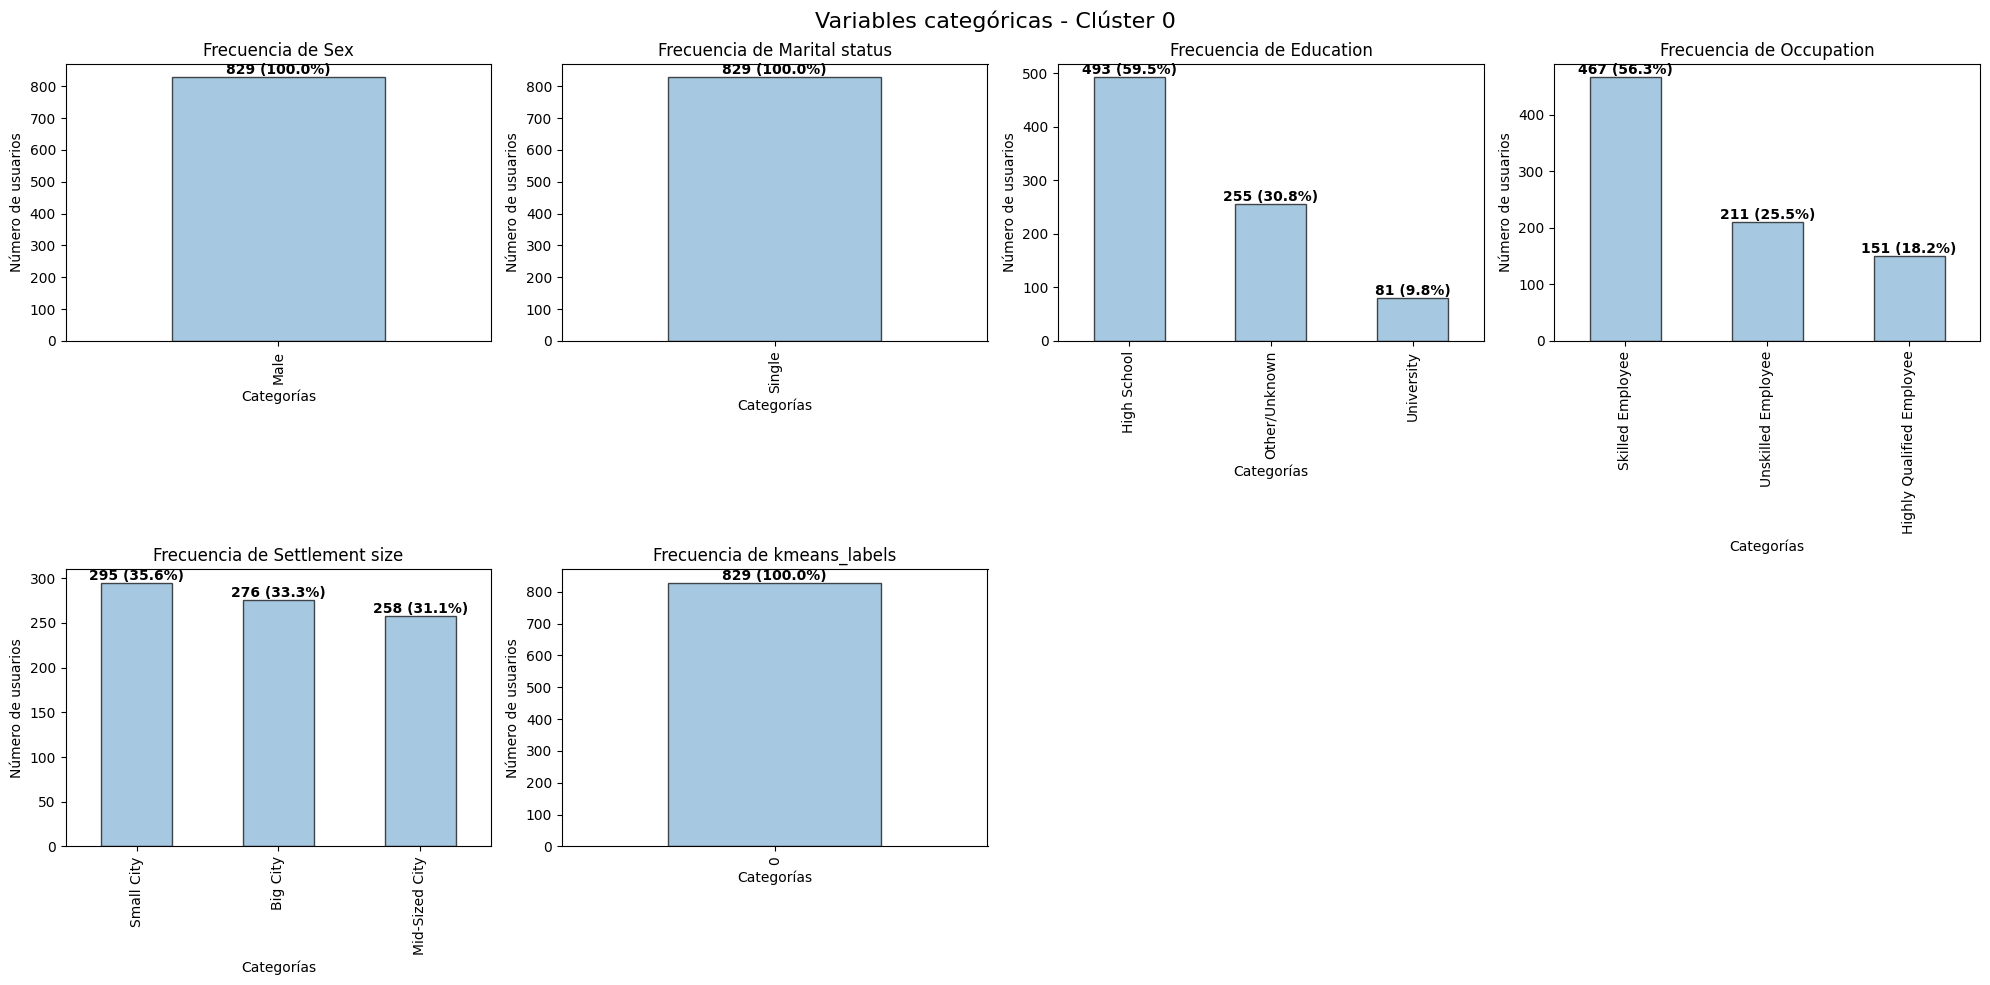

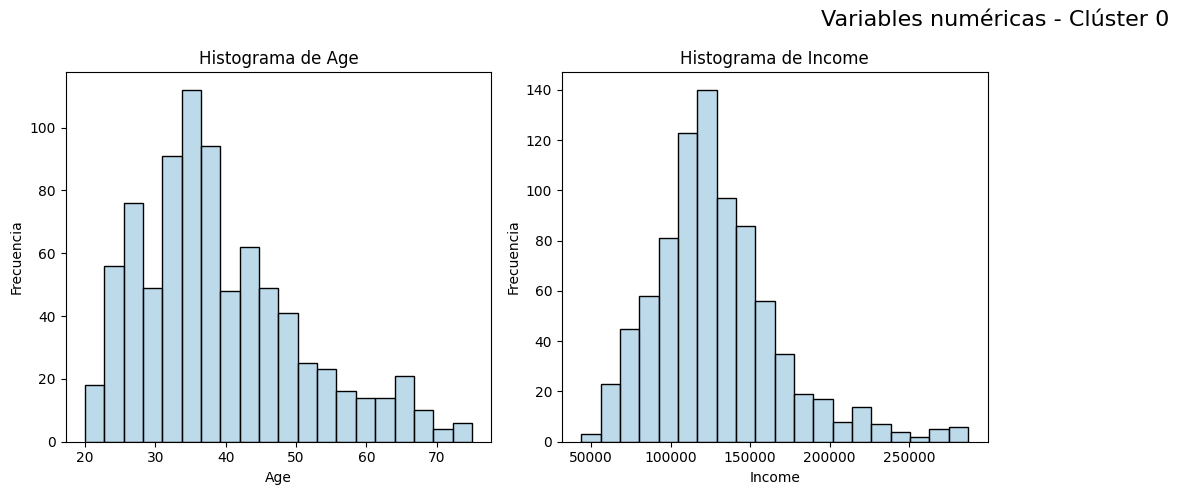

In [ ]:
graficar_cluster_hist(cluster_0, nombre='Clúster 0')

El Clúster 0 representa un perfil claramente definido formado exclusivamente por **hombres solteros**, con un nivel educativo mayoritariamente de **secundaria (high school)** y una ocupación centrada en el perfil de **empleado cualificado (skilled employee)**. Aunque hay cierta variabilidad en la categoría de ciudad, destaca una distribución equilibrada entre **ciudades pequeñas, medianas y grandes**, sin un entorno urbano dominante. A nivel numérico, la mayoría de los usuarios tienen entre **30 y 40 años**, lo que indica una población **joven-adulta**, y presentan un **nivel de ingresos medio-alto**, concentrado principalmente entre los **90 000 y 140 000 USD**. En conjunto, este clúster agrupa a **hombres jóvenes, solteros, con empleos estables y buen poder adquisitivo**, lo que lo convierte en un segmento muy útil para estrategias comerciales dirigidas a consumidores individuales con autonomía económica y sin cargas familiares.


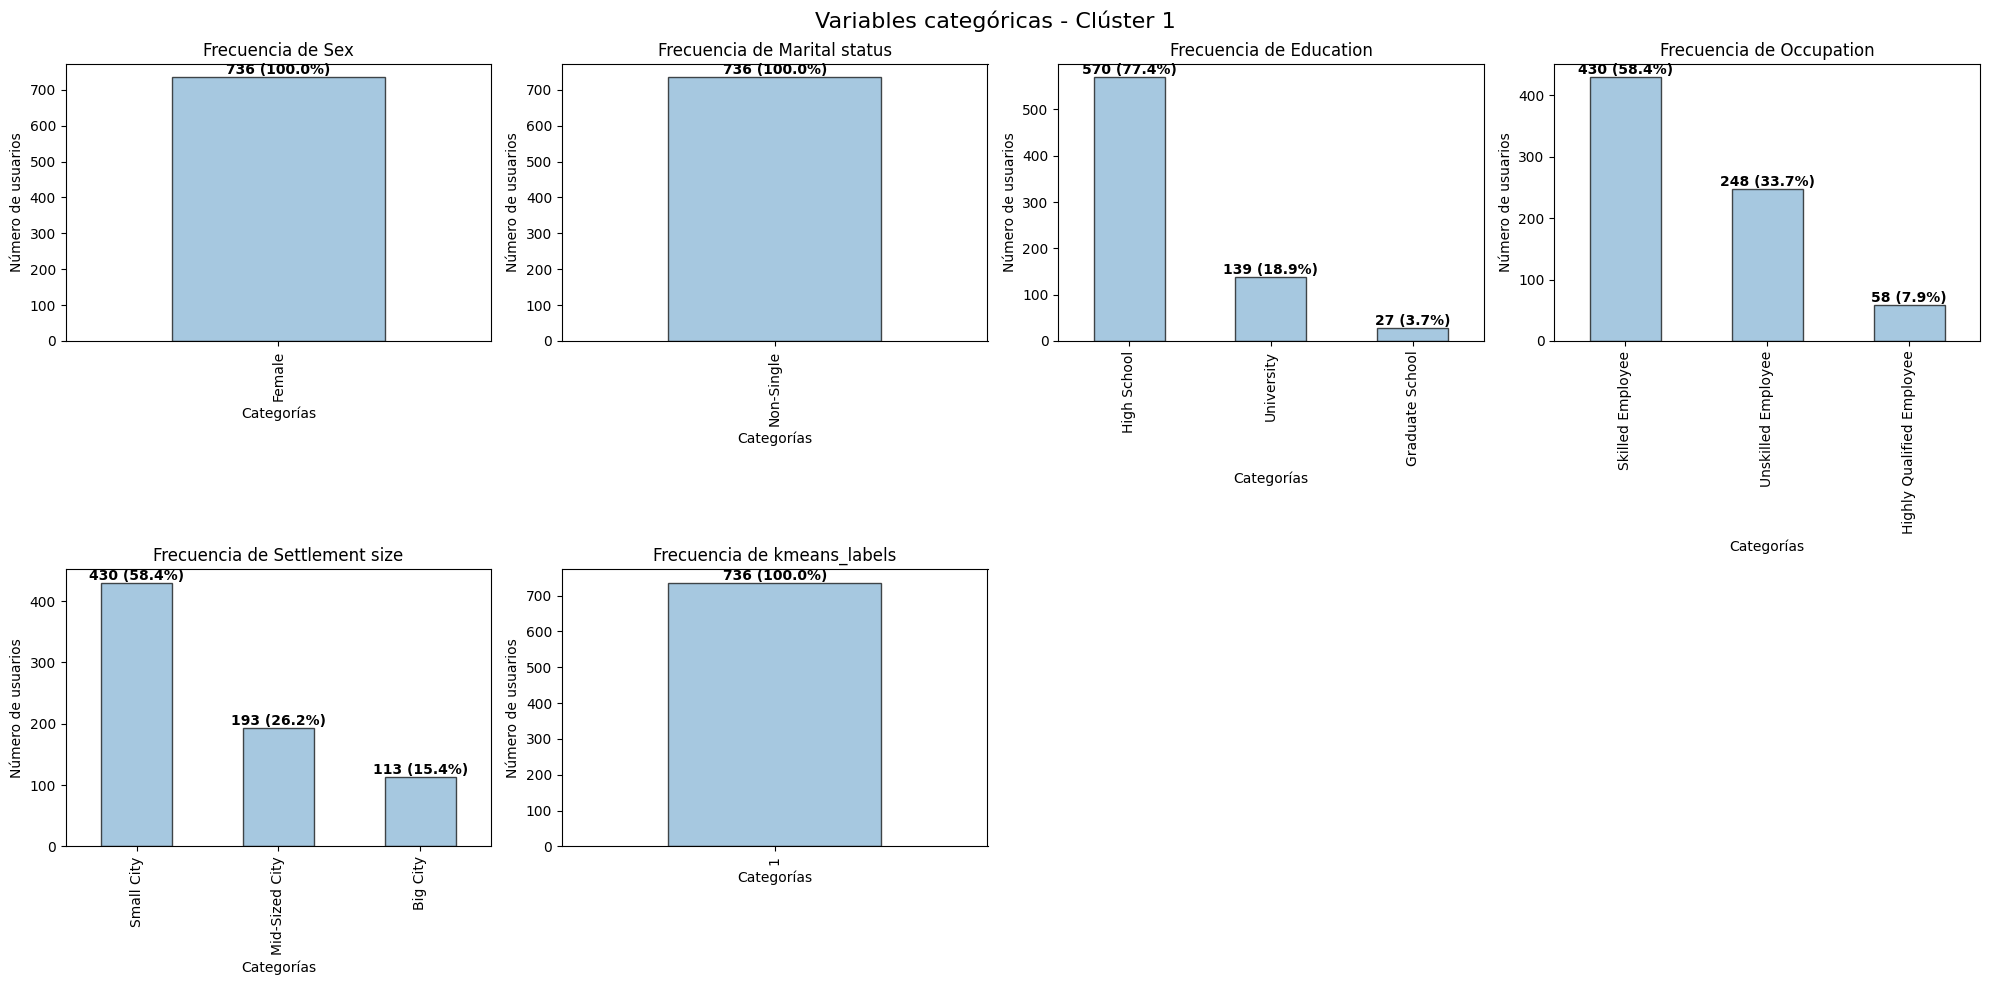

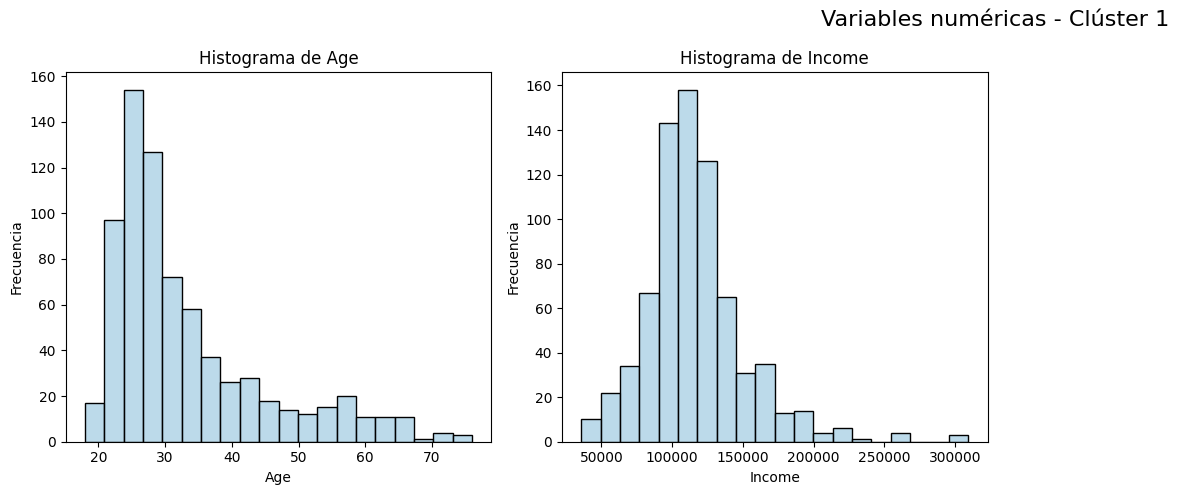

In [ ]:
graficar_cluster_hist(cluster_1, nombre='Clúster 1')

El Clúster 1 agrupa exclusivamente a **mujeres** en situación de **no solteras** (casadas, separadas, viudas o divorciadas), lo que lo convierte en un grupo altamente homogéneo en cuanto a sexo y estado civil. La mayoría tiene estudios de **secundaria (77.4 %)**, seguidas por un 18.9 % con estudios universitarios y solo un 3.7 % con formación de posgrado. En cuanto a ocupación, predominan las **empleadas cualificadas (58.4 %)**, aunque también hay un 33.7 % con empleos no cualificados y una pequeña proporción (7.9 %) de perfiles altamente cualificados. La mayoría reside en **ciudades pequeñas (58.4 %)**, y en menor medida en medianas (26.2 %) y grandes (15.4 %).

Desde el punto de vista numérico, este grupo presenta un perfil **más joven**, con un pico de edad entre los **25 y 30 años**, y una distribución de ingresos centrada entre los **90 000 y 140 000 USD**, similar al clúster anterior, aunque con más dispersión hacia los tramos bajos.

En conjunto, este clúster representa a **mujeres adultas jóvenes, con pareja o expareja, nivel educativo medio y empleo estable, residentes sobre todo en poblaciones pequeñas y con un nivel de ingresos medio-alto**. Es un segmento valioso para estrategias dirigidas a hogares consolidados o familias jóvenes con estabilidad económica.


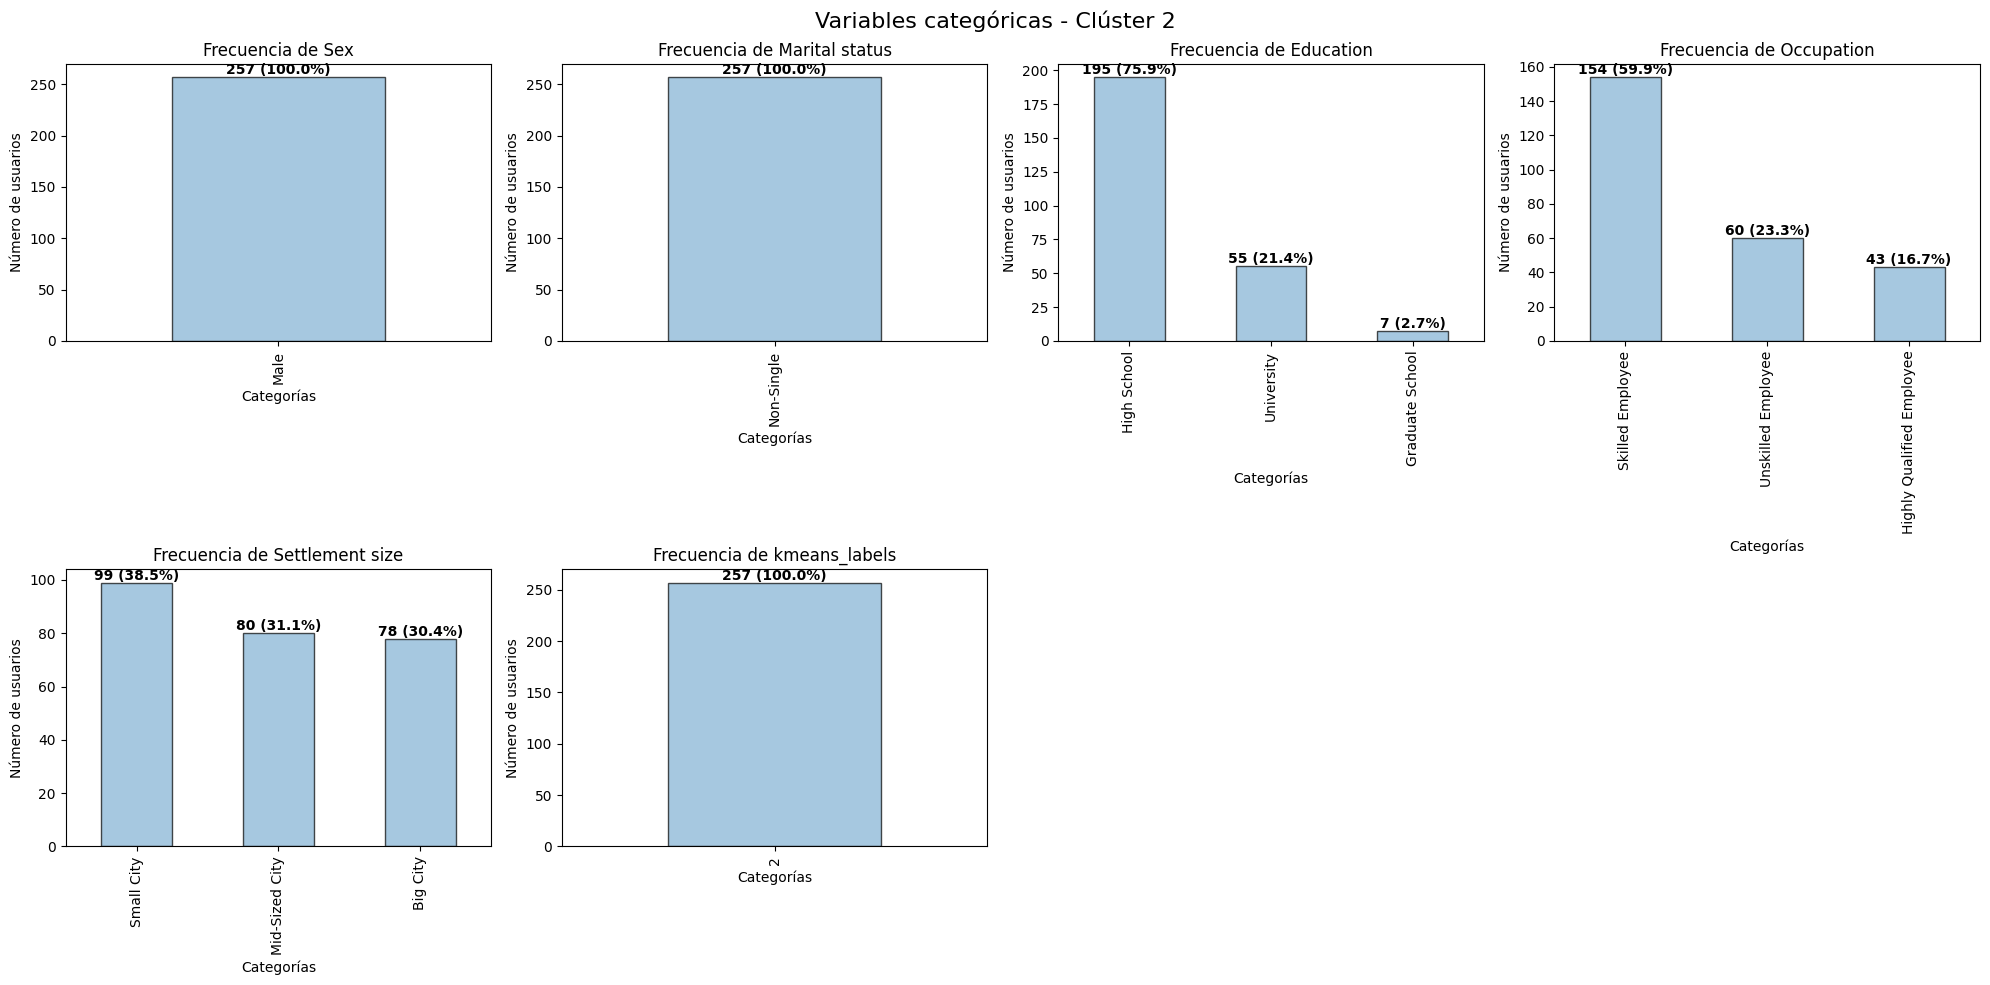

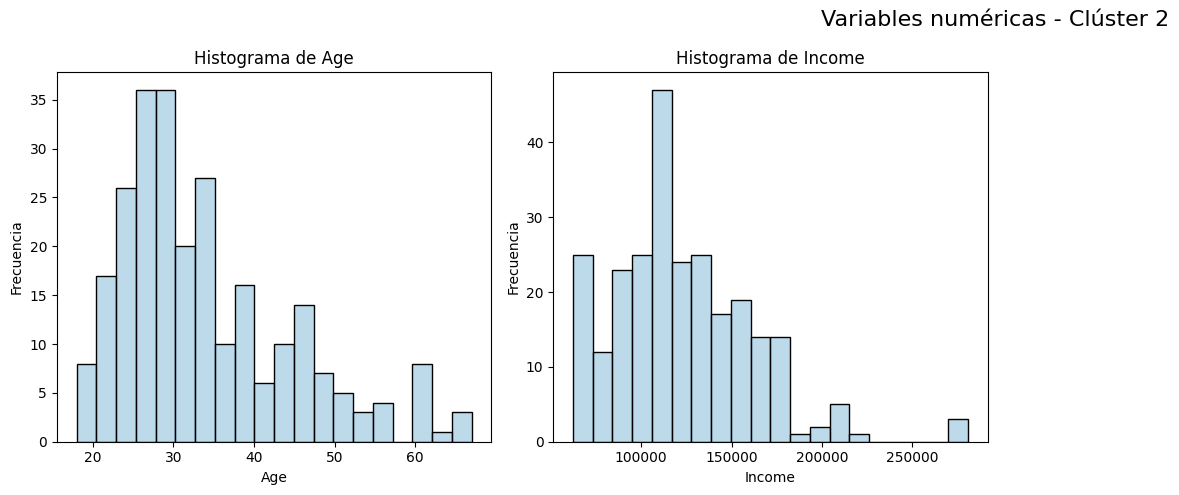

In [ ]:
graficar_cluster_hist(cluster_2, nombre='Clúster 2')

El Clúster 2 está compuesto únicamente por **hombres en situación no soltera** (casados, separados, viudos o divorciados). En cuanto al nivel educativo, predominan los estudios de **secundaria (75.9 %)**, seguidos por estudios universitarios (21.4 %) y una pequeña proporción con formación de posgrado (2.7 %). En el ámbito laboral, la mayoría trabaja como **empleado cualificado (59.9 %)**, con un 23.3 % en empleos no cualificados y sin presencia de perfiles altamente cualificados. En cuanto al tamaño del municipio, la distribución está bastante equilibrada: **Small City (38.5 %)**, **Mid-Sized City (31.1 %)** y **Big City (30.4 %)**, sin un entorno dominante.

Desde el punto de vista numérico, la edad se concentra principalmente entre los **25 y 40 años**, lo que indica un perfil **adulto joven**, con una ligera dispersión hacia edades mayores. En cuanto a los ingresos, la mayoría se sitúa entre **90 000 y 150 000 USD**, con una distribución que muestra cierta variabilidad hacia ambos extremos, aunque sigue predominando el perfil de **ingresos medios**.

En conjunto, el Clúster 2 agrupa a **hombres adultos jóvenes, en pareja o expareja, con formación media, empleo técnico estable y poder adquisitivo medio**, repartidos de forma bastante equilibrada entre distintos tamaños de ciudad. Es un segmento interesante para campañas dirigidas a hogares masculinos con estabilidad personal y económica, pero sin un perfil educativo ni profesional altamente especializado.


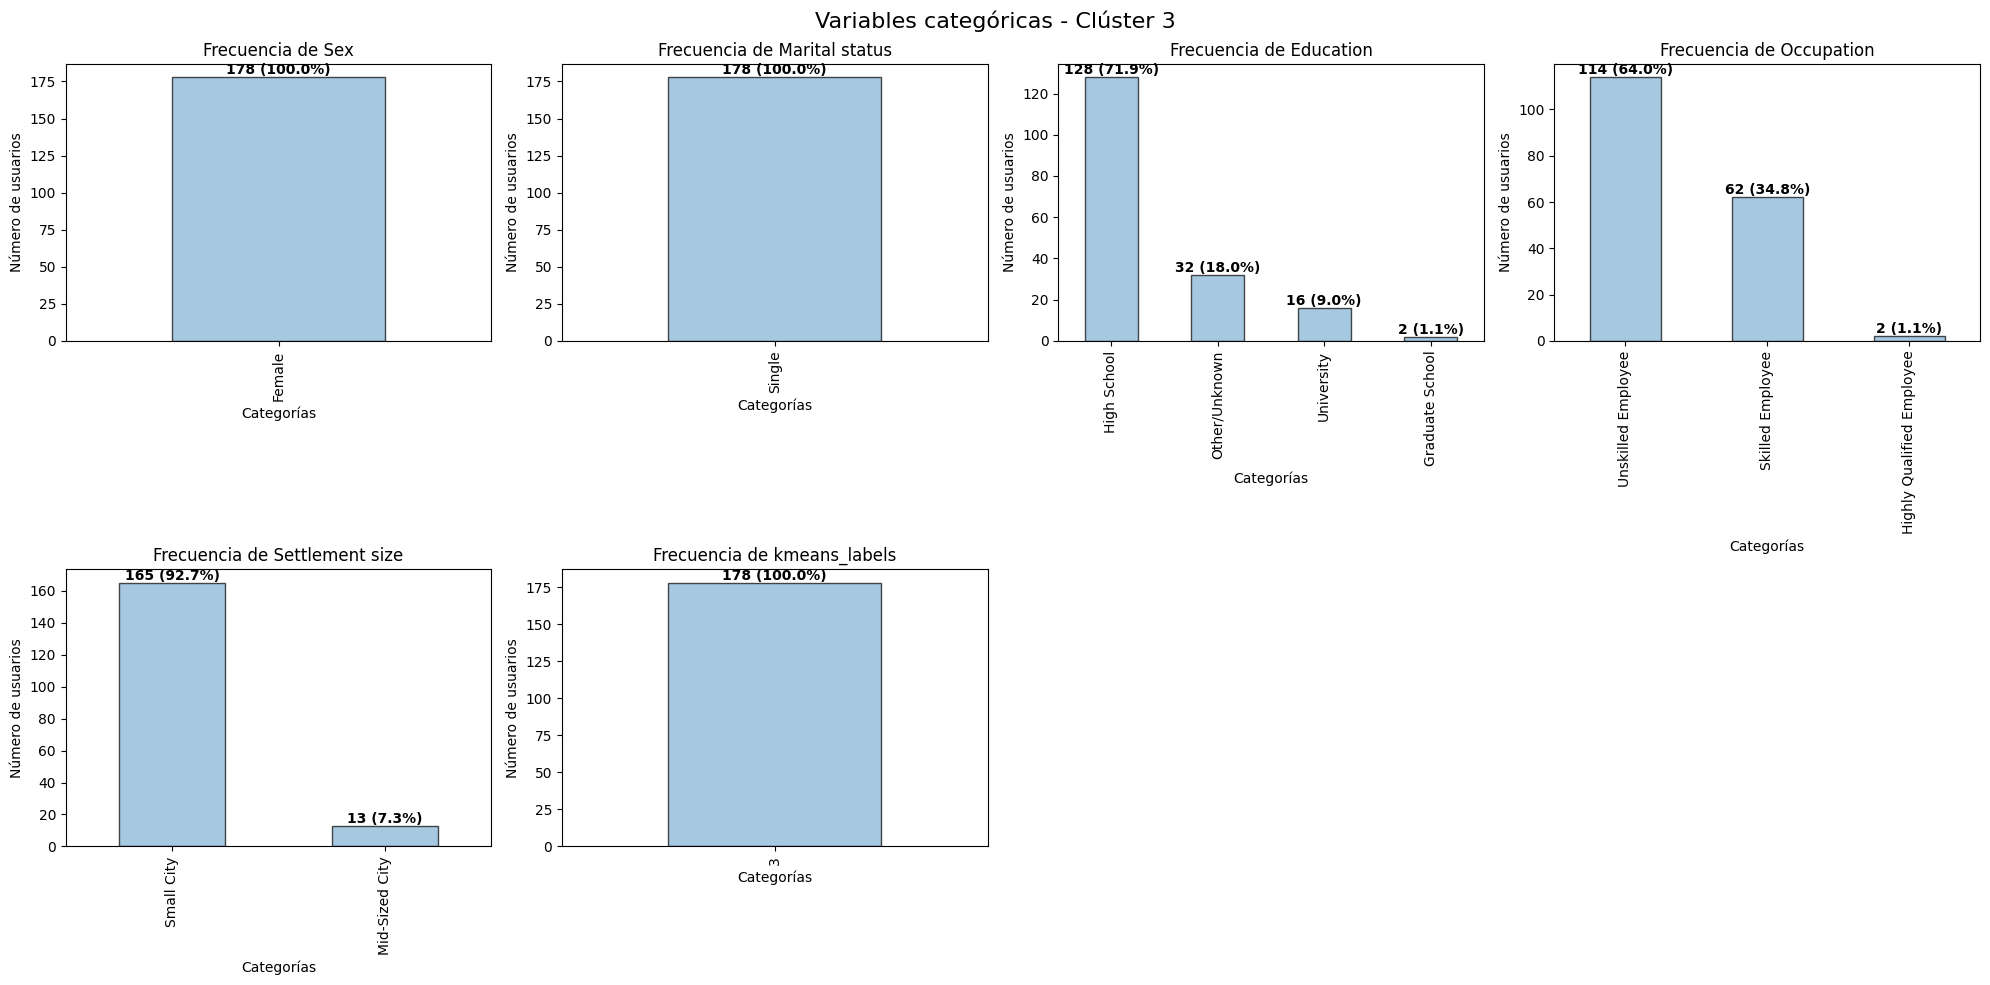

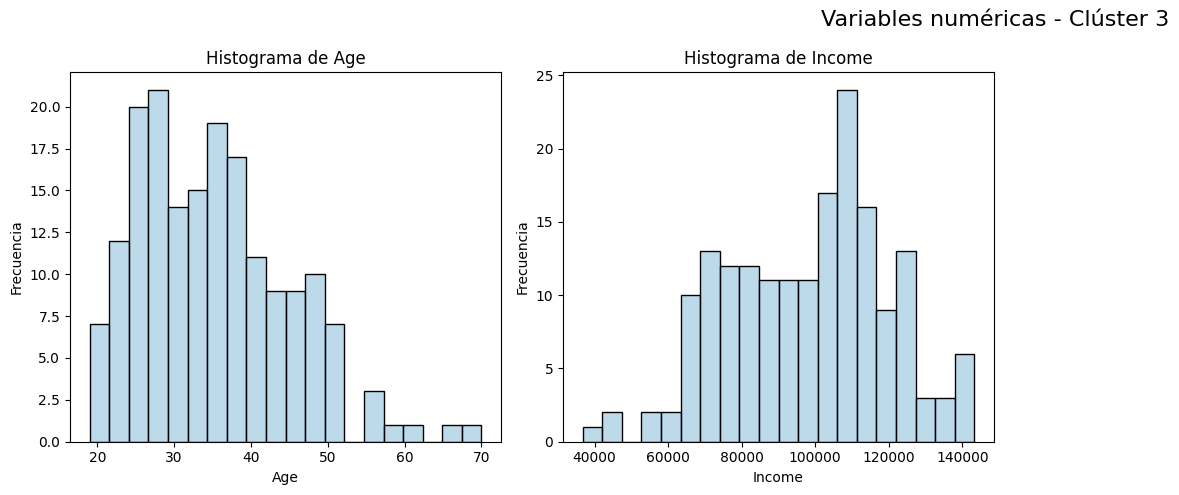

In [ ]:
graficar_cluster_hist(cluster_3, nombre='Clúster 3')

El Clúster 3 está formado exclusivamente por **mujeres solteras**, lo que lo define con claridad a nivel demográfico. En cuanto al nivel educativo, la mayoría tiene estudios de **secundaria (71.9 %)**, seguido de un 18 % con nivel desconocido u otros, y solo un 9 % con estudios universitarios. A nivel laboral, predominan claramente las **empleadas no cualificadas (64 %)**, por encima de las cualificadas (34.8 %) y apenas un 1.1 % con perfil altamente cualificado. Geográficamente, este clúster es muy homogéneo: el **92.7 % reside en ciudades pequeñas**, lo que refuerza su identidad como grupo concentrado en entornos urbanos reducidos.

Desde el punto de vista numérico, la edad se distribuye principalmente entre los **25 y 40 años**, con un perfil claramente adulto joven. En cuanto a ingresos, este grupo muestra una tendencia centrada entre los **75 000 y 120 000 USD**, pero con una presencia notable de valores más bajos, lo que sugiere un poder adquisitivo **ligeramente inferior** al de otros clústers analizados.

En conjunto, el Clúster 3 representa a **mujeres jóvenes, solteras, con formación media o baja, empleos principalmente no cualificados y residentes en ciudades pequeñas**. Es un perfil útil para campañas dirigidas a consumidoras individuales en zonas no metropolitanas, con sensibilidad a precio y preferencias locales.


# Resumen de las principales diferencias entre clústeres
El **Clúster 0** agrupa a hombres solteros, con estudios mayoritariamente de secundaria, ocupación técnica cualificada y buena capacidad económica, repartidos en todos los tamaños de ciudad.

El **Clúster 1**, en cambio, está formado por mujeres no solteras, también con formación media, empleadas cualificadas, residentes sobre todo en ciudades pequeñas y con un nivel de ingresos estable.

El **Clúster 2** representa a hombres no solteros, con características similares al Clúster 0 pero con ingresos algo más repartidos y sin presencia de perfiles altamente cualificados.

El **Clúster 3** reúne a mujeres jóvenes, solteras, con empleos principalmente no cualificados, ingresos más bajos y una clara concentración en ciudades pequeñas. Las principales diferencias entre clústeres se encuentran en el sexo, el estado civil, el tipo de ocupación y el entorno de residencia, lo que permite identificar perfiles sociodemográficos bien definidos y útiles para estrategias diferenciadas.